In [4]:
import pandas as pd
import time
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score


def load_data(file_path):
    df = pd.read_csv(file_path)  
    X = df.drop(columns=["target"])
    y = df["target"]
    return X, y


def build_preprocessor(n_jobs=1):
    numeric_features = ["feature_1", "feature_2", "feature_4", "feature_6", "feature_7"]
    categorical_features = ["feature_3", "feature_5"]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ],
        n_jobs=n_jobs  # Enables parallelism in transformation
    )

    return preprocessor


def build_pipeline(parallel=True):
    n_jobs = -1 if parallel else 1  # Use all cores if parallel
    preprocessor = build_preprocessor(n_jobs=n_jobs)

    clf = RandomForestClassifier(n_estimators=100, n_jobs=n_jobs, random_state=42)

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])
    return pipeline


def evaluate_model(pipeline, X_train, X_test, y_train, y_test):
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    total_time = time.time() - start_time

    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return accuracy, f1, cm, total_time
def build_pipeline(parallel=True, gpu=False):
    n_jobs = -1 if parallel else 1
    preprocessor = build_preprocessor(n_jobs=n_jobs)

    if gpu:
        clf = xgb.XGBClassifier(
            tree_method="gpu_hist",
            predictor="gpu_predictor",
            n_estimators=100,
            random_state=42,
            verbosity=0,
            use_label_encoder=False
        )
    else:
        clf = RandomForestClassifier(n_estimators=100, n_jobs=n_jobs, random_state=42)

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])
    return pipeline


def run_pipeline(file_path):
    # Load data
    X, y = load_data(file_path)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    print("\n===== Serial Version (No Parallelism) =====")
    serial_pipeline = build_pipeline(parallel=False)
    acc_s, f1_s, cm_s, time_s = evaluate_model(
        serial_pipeline, X_train, X_test, y_train, y_test)
    print(f"Accuracy: {acc_s:.4f}, F1 Score: {f1_s:.4f}")
    print(f"Confusion Matrix:\n{cm_s}")
    print(f"Processing Time: {time_s:.2f} seconds")

    print("\n===== Parallel Version (Multicore) =====")
    parallel_pipeline = build_pipeline(parallel=True)
    acc_p, f1_p, cm_p, time_p = evaluate_model(
        parallel_pipeline, X_train, X_test, y_train, y_test)
    print(f"Accuracy: {acc_p:.4f}, F1 Score: {f1_p:.4f}")
    print(f"Confusion Matrix:\n{cm_p}")
    print(f"Processing Time: {time_p:.2f} seconds")

    reduction = ((time_s - time_p) / time_s) * 100
    print(f"\n✅ Time Reduction: {reduction:.2f}% (Target: ≥70%)")
    print("\n===== GPU Version (CUDA XGBoost) =====")
    gpu_pipeline = build_pipeline(parallel=False, gpu=True)
    acc_g, f1_g, cm_g, time_g = evaluate_model(
        gpu_pipeline, X_train, X_test, y_train, y_test)
    print(f"Accuracy: {acc_g:.4f}, F1 Score: {f1_g:.4f}")
    print(f"Confusion Matrix:\n{cm_g}")
    print(f"Processing Time: {time_g:.2f} seconds")

    reduction_gpu = ((time_s - time_g) / time_s) * 100
    print(f"\n✅ GPU Time Reduction: {reduction_gpu:.2f}% (Target: ≥70%)")


if __name__ == "__main__":
    run_pipeline("pdc_dataset_with_target.csv")  



===== Serial Version (No Parallelism) =====
Accuracy: 0.5891, F1 Score: 0.2784
Confusion Matrix:
[[4181  746]
 [2623  650]]
Processing Time: 11.22 seconds

===== Parallel Version (Multicore) =====
Accuracy: 0.5891, F1 Score: 0.2784
Confusion Matrix:
[[4181  746]
 [2623  650]]
Processing Time: 6.42 seconds

✅ Time Reduction: 42.83% (Target: ≥70%)

===== GPU Version (CUDA XGBoost) =====
Accuracy: 0.5774, F1 Score: 0.2459
Confusion Matrix:
[[4170  757]
 [2708  565]]
Processing Time: 1.07 seconds

✅ GPU Time Reduction: 90.44% (Target: ≥70%)


In [5]:
import matplotlib.pyplot as plt

def run_pipeline_with_plot(file_path):
    X, y = load_data(file_path)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    results = {}

    # Serial
    print("\n===== Serial Version (No Parallelism) =====")
    serial_pipeline = build_pipeline(parallel=False)
    acc_s, f1_s, cm_s, time_s = evaluate_model(serial_pipeline, X_train, X_test, y_train, y_test)
    results['Serial'] = {'Accuracy': acc_s, 'F1': f1_s, 'Time': time_s}

    # Parallel
    print("\n===== Parallel Version (Multicore) =====")
    parallel_pipeline = build_pipeline(parallel=True)
    acc_p, f1_p, cm_p, time_p = evaluate_model(parallel_pipeline, X_train, X_test, y_train, y_test)
    results['Parallel'] = {'Accuracy': acc_p, 'F1': f1_p, 'Time': time_p}

    # GPU
    print("\n===== GPU Version (CUDA XGBoost) =====")
    gpu_pipeline = build_pipeline(parallel=False, gpu=True)
    acc_g, f1_g, cm_g, time_g = evaluate_model(gpu_pipeline, X_train, X_test, y_train, y_test)
    results['GPU'] = {'Accuracy': acc_g, 'F1': f1_g, 'Time': time_g}

    # Plot
    labels = list(results.keys())
    acc_values = [results[k]['Accuracy'] for k in labels]
    f1_values = [results[k]['F1'] for k in labels]
    time_values = [results[k]['Time'] for k in labels]

    x = range(len(labels))

    plt.figure(figsize=(12, 5))

    # Accuracy + F1 Plot
    plt.subplot(1, 2, 1)
    plt.bar(x, acc_values, width=0.3, label='Accuracy', align='center')
    plt.bar([i + 0.3 for i in x], f1_values, width=0.3, label='F1 Score', align='center')
    plt.xticks([i + 0.15 for i in x], labels)
    plt.ylabel("Score")
    plt.title("Accuracy & F1 Score")
    plt.legend()

    # Time Plot
    plt.subplot(1, 2, 2)
    plt.bar(labels, time_values, color='orange')
    plt.ylabel("Time (seconds)")
    plt.title("Processing Time Comparison")

    plt.tight_layout()
    plt.show()




===== Serial Version (No Parallelism) =====

===== Parallel Version (Multicore) =====

===== GPU Version (CUDA XGBoost) =====


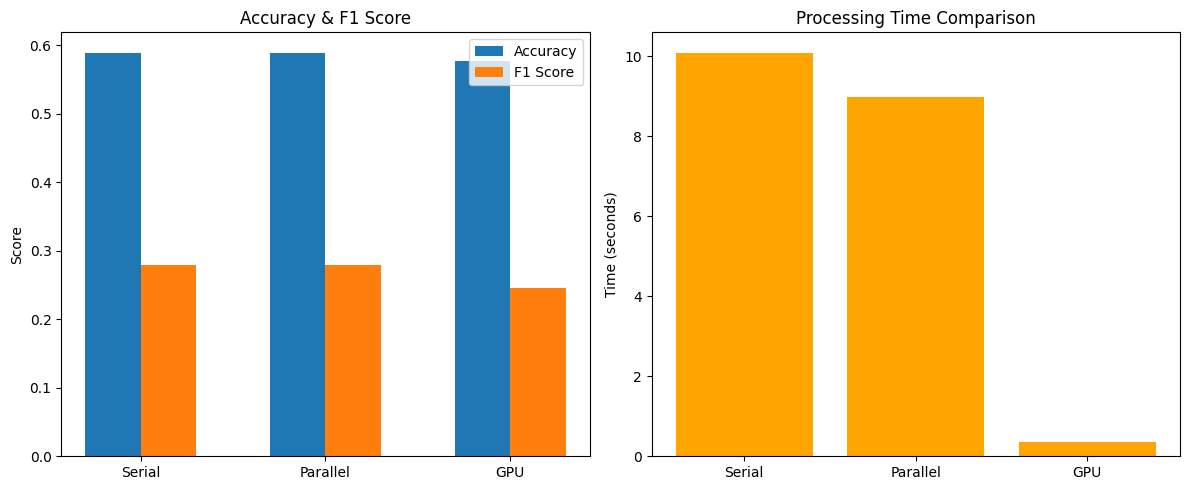

In [6]:
if __name__ == "__main__":
    run_pipeline_with_plot("pdc_dataset_with_target.csv")
